### Step 1 — Mount + imports + paths

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import json
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

BASE_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose")
SPLIT_DIR = BASE_DIR / "data" / "splits"
CKPT_DIR = BASE_DIR / "outputs" / "checkpoints"
OUT_DIR = BASE_DIR / "analysis" / "ct2dose_phase4_bone_aware_mixed_training"

OUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_MANIFEST = SPLIT_DIR / "train_pairs_3d_train_phase3_2000.json"
VAL_MANIFEST   = SPLIT_DIR / "train_pairs_3d_val_phase3_500.json"

print("TRAIN_MANIFEST exists:", TRAIN_MANIFEST.exists())
print("VAL_MANIFEST exists:", VAL_MANIFEST.exists())

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

Mounted at /content/drive
TRAIN_MANIFEST exists: True
VAL_MANIFEST exists: True
device: cuda


### Cell 2 — Optional title

In [2]:
from IPython.display import Markdown, display

display(Markdown(r"""
# CT-to-Dose Phase 4: Bone-Aware Mixed Training
## Run: ct2dose_phase4_bone_aware_mixed_flow_lr5e4_base24_bs2_T0p10_a0p30_mw3_bf2
### Goal: keep T=0.10, alpha=0.30, max_weight=3.0, but oversample bone-in-beam candidate training cases
"""))


# CT-to-Dose Phase 4: Bone-Aware Mixed Training
## Run: ct2dose_phase4_bone_aware_mixed_flow_lr5e4_base24_bs2_T0p10_a0p30_mw3_bf2
### Goal: keep T=0.10, alpha=0.30, max_weight=3.0, but oversample bone-in-beam candidate training cases


### Cell 3 — Dataset + model definitions

In [3]:
DOSE_SCALE = 1000.0
EPS = 1e-8

def normalize_ct(x):
    x = np.clip(x, -1024.0, 1500.0)
    x = (x + 1024.0) / (1500.0 + 1024.0)
    return x.astype(np.float32)

def denormalize_ct(x_norm):
    return x_norm * (1500.0 + 1024.0) - 1024.0

class CubePair3DDataset(Dataset):
    def __init__(self, manifest_path, dose_scale=1000.0):
        with open(manifest_path, "r", encoding="utf-8") as f:
            self.records = json.load(f)
        self.dose_scale = dose_scale

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        x0 = np.load(rec["input_path"]).astype(np.float32)
        x1 = np.load(rec["output_path"]).astype(np.float32)

        x0 = normalize_ct(x0)
        x1 = (x1 * self.dose_scale).astype(np.float32)

        x0 = torch.from_numpy(x0).unsqueeze(0)
        x1 = torch.from_numpy(x1).unsqueeze(0)

        return x0, x1


class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ConditionalUNetFlow3D(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base_ch=24):
        super().__init__()

        self.enc1 = DoubleConv3D(in_ch, base_ch)
        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv3D(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool3d(2)

        self.bottleneck = DoubleConv3D(base_ch * 2, base_ch * 4)

        self.up2 = nn.ConvTranspose3d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv3D(base_ch * 4, base_ch * 2)

        self.up1 = nn.ConvTranspose3d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.dec1 = DoubleConv3D(base_ch * 2, base_ch)

        self.out_conv = nn.Conv3d(base_ch, out_ch, kernel_size=1)

    def forward(self, xt, x0, t):
        t_map = t.expand(-1, 1, xt.shape[2], xt.shape[3], xt.shape[4])
        inp = torch.cat([xt, x0, t_map], dim=1)

        e1 = self.enc1(inp)
        e2 = self.enc2(self.pool1(e1))
        b  = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)


@torch.no_grad()
def euler_sample_flow_3d(model, x0, n_steps=30):
    model.eval()
    z = x0.clone()
    dt = 1.0 / n_steps
    for k in range(n_steps):
        t = torch.full((z.shape[0], 1, 1, 1, 1), k / n_steps, device=z.device)
        v = model(z, x0, t)
        z = z + dt * v
    return z


def sample_t_like(x):
    return torch.rand((x.shape[0], 1, 1, 1, 1), device=x.device)

### Cell 4 — Config

In [4]:
RUN_NAME = "ct2dose_phase4_bone_aware_mixed_flow_lr5e4_base24_bs2_T0p10_a0p30_mw3_bf2"

LR = 5e-4
BATCH_SIZE = 2
EPOCHS = 50
BASE_CH = 24

THRESHOLD = 0.10
THRESHOLD_MODE = "absolute"

ALPHA = 0.30
MAX_WEIGHT = 3.0

# bone-aware sampling
BONE_BAND_HALFWIDTH = 1
BONE_HU_THRESHOLD = 300.0
BONE_MIN_FRACTION = 0.05
BONE_SAMPLING_FACTOR = 2.0   # 推荐先从 2.0 开始
SAMPLER_NUM_SAMPLES = None   # None -> use len(train_dataset)

best_ckpt_path = CKPT_DIR / f"{RUN_NAME}_best.pt"
latest_ckpt_path = CKPT_DIR / f"{RUN_NAME}_latest.pt"
log_csv_path = OUT_DIR / f"{RUN_NAME}_training_log.csv"
summary_json_path = OUT_DIR / f"{RUN_NAME}_summary.json"
train_label_csv_path = OUT_DIR / f"{RUN_NAME}_train_bone_labels.csv"

print("RUN_NAME:", RUN_NAME)
print("THRESHOLD:", THRESHOLD)
print("ALPHA:", ALPHA)
print("MAX_WEIGHT:", MAX_WEIGHT)
print("BONE_SAMPLING_FACTOR:", BONE_SAMPLING_FACTOR)

RUN_NAME: ct2dose_phase4_bone_aware_mixed_flow_lr5e4_base24_bs2_T0p10_a0p30_mw3_bf2
THRESHOLD: 0.1
ALPHA: 0.3
MAX_WEIGHT: 3.0
BONE_SAMPLING_FACTOR: 2.0


### Cell 5 — Loss functions

In [5]:
def build_weight_map_from_gt(gt_dose, threshold=0.10, mode="absolute", eps=1e-8):
    if mode == "absolute":
        T = torch.full_like(gt_dose, fill_value=threshold)
    elif mode == "relative_to_case_max":
        case_max = gt_dose.amax(dim=(1,2,3,4), keepdim=True)
        T = threshold * case_max.expand_as(gt_dose)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    T = torch.clamp(T, min=eps)
    weight = torch.maximum(T, gt_dose) / T
    return weight


def compute_mixed_weighted_flow_matching_loss(
    model,
    x0,
    x1,
    threshold=0.10,
    mode="absolute",
    alpha=0.30,
    max_weight=None,
    eps=1e-8
):
    t = sample_t_like(x0)
    z_t = (1.0 - t) * x0 + t * x1

    v_target = x1 - x0
    v_pred = model(z_t, x0, t)

    sq_err = (v_pred - v_target) ** 2
    base_loss = sq_err.mean()

    weight = build_weight_map_from_gt(
        x1, threshold=threshold, mode=mode, eps=eps
    )

    if max_weight is not None:
        weight = torch.clamp(weight, max=max_weight)

    weighted_loss = (weight * sq_err).sum() / (weight.sum() + eps)
    final_loss = (1.0 - alpha) * base_loss + alpha * weighted_loss

    aux = {
        "base_loss": float(base_loss.item()),
        "weighted_loss": float(weighted_loss.item()),
        "final_loss": float(final_loss.item()),
        "weight_mean": float(weight.mean().item()),
        "weight_max": float(weight.max().item()),
    }
    return final_loss, aux

### Cell 6 — Bone heuristic on dataset samples

In [6]:
def find_best_dose_slice_index(volume):
    slice_sums = volume.reshape(volume.shape[0], -1).sum(axis=1)
    return int(np.argmax(slice_sums))

def find_peak_xy(volume, slice_idx):
    slice_2d = volume[slice_idx]
    return np.unravel_index(np.argmax(slice_2d), slice_2d.shape)

def compute_bone_in_beam_heuristic_from_sample(
    ct_vol_norm,
    gt_vol,
    threshold=0.10,
    band_halfwidth=1,
    bone_hu_threshold=300.0,
    min_bone_fraction=0.05
):
    slice_idx = find_best_dose_slice_index(gt_vol)
    peak_y, peak_x = find_peak_xy(gt_vol, slice_idx)

    gt_slice = gt_vol[slice_idx]
    ct_slice_hu = denormalize_ct(ct_vol_norm[slice_idx])

    y0 = max(0, peak_y - band_halfwidth)
    y1 = min(gt_slice.shape[0], peak_y + band_halfwidth + 1)

    dose_band = gt_slice[y0:y1, :]
    ct_band_hu = ct_slice_hu[y0:y1, :]

    relevant_mask = dose_band >= threshold

    if relevant_mask.sum() == 0:
        bone_fraction = 0.0
        max_hu = float(np.max(ct_band_hu))
        candidate = False
    else:
        bone_mask = (ct_band_hu >= bone_hu_threshold) & relevant_mask
        bone_fraction = float(bone_mask.sum() / relevant_mask.sum())
        max_hu = float(np.max(ct_band_hu[relevant_mask]))
        candidate = bone_fraction >= min_bone_fraction

    return {
        "bone_in_beam_candidate": bool(candidate),
        "bone_fraction_in_relevant_band": float(bone_fraction),
        "max_hu_in_relevant_band": float(max_hu),
        "beam_slice_idx": int(slice_idx),
        "beam_peak_y": int(peak_y),
        "beam_peak_x": int(peak_x),
    }

### Cell 7 — Build train/val datasets

In [7]:
train_dataset_3d = CubePair3DDataset(TRAIN_MANIFEST, dose_scale=DOSE_SCALE)
val_dataset_3d   = CubePair3DDataset(VAL_MANIFEST, dose_scale=DOSE_SCALE)

print("Train samples:", len(train_dataset_3d))
print("Val samples:", len(val_dataset_3d))

Train samples: 2000
Val samples: 500


### Cell 8 — Label the training set

In [8]:
train_label_rows = []

for idx in range(len(train_dataset_3d)):
    x0, x1 = train_dataset_3d[idx]
    ct_vol = x0.squeeze().numpy()
    gt_vol = x1.squeeze().numpy()

    bone_info = compute_bone_in_beam_heuristic_from_sample(
        ct_vol_norm=ct_vol,
        gt_vol=gt_vol,
        threshold=THRESHOLD,
        band_halfwidth=BONE_BAND_HALFWIDTH,
        bone_hu_threshold=BONE_HU_THRESHOLD,
        min_bone_fraction=BONE_MIN_FRACTION
    )

    train_label_rows.append({
        "sample_idx": idx,
        **bone_info
    })

train_label_df = pd.DataFrame(train_label_rows)
train_label_df.to_csv(train_label_csv_path, index=False)

print("Saved:", train_label_csv_path)
display(train_label_df.head())
print("Bone candidate count:", int(train_label_df["bone_in_beam_candidate"].sum()))
print("Non-bone count:", int((~train_label_df["bone_in_beam_candidate"]).sum()))

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_bone_aware_mixed_training/ct2dose_phase4_bone_aware_mixed_flow_lr5e4_base24_bs2_T0p10_a0p30_mw3_bf2_train_bone_labels.csv


,sample_idx,bone_in_beam_candidate,bone_fraction_in_relevant_band,max_hu_in_relevant_band,beam_slice_idx,beam_peak_y,beam_peak_x
0,0,False,0.025,401.843506,16,16,0
1,1,False,0.000,24.829956,16,16,0
2,2,False,0.000,24.351318,16,16,0
3,3,False,0.000,24.727051,16,16,0
4,4,True,0.175,638.339478,16,16,0


Bone candidate count: 609
Non-bone count: 1391


### Cell 9 — Build sample weights + sampler

In [9]:
sample_weights = np.ones(len(train_dataset_3d), dtype=np.float64)

bone_mask = train_label_df["bone_in_beam_candidate"].values.astype(bool)
sample_weights[bone_mask] = BONE_SAMPLING_FACTOR

sample_weights_torch = torch.as_tensor(sample_weights, dtype=torch.double)

num_samples = len(train_dataset_3d) if SAMPLER_NUM_SAMPLES is None else SAMPLER_NUM_SAMPLES

train_sampler = WeightedRandomSampler(
    weights=sample_weights_torch,
    num_samples=num_samples,
    replacement=True
)

print("Sample weight stats:")
print("min =", float(sample_weights.min()))
print("max =", float(sample_weights.max()))
print("mean =", float(sample_weights.mean()))
print("bone factor applied to", int(bone_mask.sum()), "samples")

Sample weight stats:
min = 1.0
max = 2.0
mean = 1.3045
bone factor applied to 609 samples


### Cell 10 — DataLoaders

In [10]:
train_loader_3d = DataLoader(
    train_dataset_3d,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=0
)

val_loader_3d = DataLoader(
    val_dataset_3d,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train loader and val loader ready.")

Train loader and val loader ready.


### Cell 11 — Train / validation loops

In [11]:
def train_one_epoch_mixed(model, loader, optimizer, device,
                          threshold=0.10, mode="absolute",
                          alpha=0.30, max_weight=3.0):
    model.train()

    total_final_loss = 0.0
    total_base_loss = 0.0
    total_weighted_loss = 0.0
    total_weight_mean = 0.0
    total_weight_max = 0.0
    total_count = 0

    for x0, x1 in loader:
        x0 = x0.to(device)
        x1 = x1.to(device)

        loss, aux = compute_mixed_weighted_flow_matching_loss(
            model, x0, x1,
            threshold=threshold,
            mode=mode,
            alpha=alpha,
            max_weight=max_weight,
            eps=EPS
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bs = x0.shape[0]
        total_final_loss += aux["final_loss"] * bs
        total_base_loss += aux["base_loss"] * bs
        total_weighted_loss += aux["weighted_loss"] * bs
        total_weight_mean += aux["weight_mean"] * bs
        total_weight_max += aux["weight_max"] * bs
        total_count += bs

    return {
        "train_final_loss": total_final_loss / total_count,
        "train_base_loss": total_base_loss / total_count,
        "train_weighted_loss": total_weighted_loss / total_count,
        "train_weight_mean": total_weight_mean / total_count,
        "train_weight_max": total_weight_max / total_count,
    }


@torch.no_grad()
def validate_one_epoch_mixed(model, loader, device,
                             threshold=0.10, mode="absolute",
                             alpha=0.30, max_weight=3.0):
    model.eval()

    total_final_loss = 0.0
    total_base_loss = 0.0
    total_weighted_loss = 0.0
    total_weight_mean = 0.0
    total_weight_max = 0.0
    total_count = 0

    for x0, x1 in loader:
        x0 = x0.to(device)
        x1 = x1.to(device)

        loss, aux = compute_mixed_weighted_flow_matching_loss(
            model, x0, x1,
            threshold=threshold,
            mode=mode,
            alpha=alpha,
            max_weight=max_weight,
            eps=EPS
        )

        bs = x0.shape[0]
        total_final_loss += aux["final_loss"] * bs
        total_base_loss += aux["base_loss"] * bs
        total_weighted_loss += aux["weighted_loss"] * bs
        total_weight_mean += aux["weight_mean"] * bs
        total_weight_max += aux["weight_max"] * bs
        total_count += bs

    return {
        "val_final_loss": total_final_loss / total_count,
        "val_base_loss": total_base_loss / total_count,
        "val_weighted_loss": total_weighted_loss / total_count,
        "val_weight_mean": total_weight_mean / total_count,
        "val_weight_max": total_weight_max / total_count,
    }

### Cell 12 — Build model + optimizer

In [12]:
model = ConditionalUNetFlow3D(in_ch=3, out_ch=1, base_ch=BASE_CH).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = []
best_val_loss = float("inf")
best_epoch = -1
start_time = time.time()

print("Model initialized.")

Model initialized.


### Cell 13 — Main training loop

In [13]:
for epoch in range(1, EPOCHS + 1):
    train_stats = train_one_epoch_mixed(
        model, train_loader_3d, optimizer, device,
        threshold=THRESHOLD,
        mode=THRESHOLD_MODE,
        alpha=ALPHA,
        max_weight=MAX_WEIGHT
    )

    val_stats = validate_one_epoch_mixed(
        model, val_loader_3d, device,
        threshold=THRESHOLD,
        mode=THRESHOLD_MODE,
        alpha=ALPHA,
        max_weight=MAX_WEIGHT
    )

    row = {"epoch": epoch, **train_stats, **val_stats}
    history.append(row)

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "run_name": RUN_NAME,
        "threshold": THRESHOLD,
        "threshold_mode": THRESHOLD_MODE,
        "alpha": ALPHA,
        "max_weight": MAX_WEIGHT,
        "bone_sampling_factor": BONE_SAMPLING_FACTOR,
        "lr": LR,
        "base_ch": BASE_CH,
    }, latest_ckpt_path)

    if val_stats["val_final_loss"] < best_val_loss:
        best_val_loss = val_stats["val_final_loss"]
        best_epoch = epoch
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "run_name": RUN_NAME,
            "threshold": THRESHOLD,
            "threshold_mode": THRESHOLD_MODE,
            "alpha": ALPHA,
            "max_weight": MAX_WEIGHT,
            "bone_sampling_factor": BONE_SAMPLING_FACTOR,
            "lr": LR,
            "base_ch": BASE_CH,
            "best_val_loss": best_val_loss
        }, best_ckpt_path)

    print(
        f"Epoch {epoch:03d} | "
        f"train_final={train_stats['train_final_loss']:.6e} | "
        f"val_final={val_stats['val_final_loss']:.6e} | "
        f"train_base={train_stats['train_base_loss']:.6e} | "
        f"val_base={val_stats['val_base_loss']:.6e} | "
        f"train_w={train_stats['train_weighted_loss']:.6e} | "
        f"val_w={val_stats['val_weighted_loss']:.6e} | "
        f"w_mean={train_stats['train_weight_mean']:.3f}"
    )

elapsed_min = (time.time() - start_time) / 60.0
print("Training finished. elapsed_min =", elapsed_min)

Epoch 001 | train_final=3.765727e-03 | val_final=7.057759e-04 | train_base=3.510444e-03 | val_base=6.804163e-04 | train_w=4.361388e-03 | val_w=7.649483e-04 | w_mean=1.065
Epoch 002 | train_final=6.959424e-04 | val_final=5.331185e-04 | train_base=6.691582e-04 | val_base=5.169992e-04 | train_w=7.584388e-04 | val_w=5.707302e-04 | w_mean=1.065
Epoch 003 | train_final=3.637790e-04 | val_final=3.004206e-04 | train_base=3.477784e-04 | val_base=2.811302e-04 | train_w=4.011137e-04 | val_w=3.454314e-04 | w_mean=1.065
Epoch 004 | train_final=2.611234e-04 | val_final=2.027836e-04 | train_base=2.474364e-04 | val_base=1.919544e-04 | train_w=2.930598e-04 | val_w=2.280516e-04 | w_mean=1.066
Epoch 005 | train_final=2.626999e-04 | val_final=2.221010e-04 | train_base=2.493777e-04 | val_base=2.098945e-04 | train_w=2.937851e-04 | val_w=2.505828e-04 | w_mean=1.065
Epoch 006 | train_final=1.904012e-04 | val_final=9.098751e-04 | train_base=1.801726e-04 | val_base=8.386147e-04 | train_w=2.142679e-04 | val_w=1.

### Cell 14 — Save logs and summary

In [14]:
history_df = pd.DataFrame(history)
history_df.to_csv(log_csv_path, index=False)

summary = {
    "run_name": RUN_NAME,
    "epochs": EPOCHS,
    "lr": LR,
    "base_ch": BASE_CH,
    "batch_size": BATCH_SIZE,
    "threshold": THRESHOLD,
    "threshold_mode": THRESHOLD_MODE,
    "alpha": ALPHA,
    "max_weight": MAX_WEIGHT,
    "bone_sampling_factor": BONE_SAMPLING_FACTOR,
    "bone_candidate_count_train": int(train_label_df["bone_in_beam_candidate"].sum()),
    "best_epoch": best_epoch,
    "best_val_loss": float(best_val_loss),
    "elapsed_min": float(elapsed_min),
    "best_ckpt_path": str(best_ckpt_path),
    "latest_ckpt_path": str(latest_ckpt_path),
}

with open(summary_json_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved:", log_csv_path)
print("Saved:", summary_json_path)
print(json.dumps(summary, indent=2))

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_bone_aware_mixed_training/ct2dose_phase4_bone_aware_mixed_flow_lr5e4_base24_bs2_T0p10_a0p30_mw3_bf2_training_log.csv
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_bone_aware_mixed_training/ct2dose_phase4_bone_aware_mixed_flow_lr5e4_base24_bs2_T0p10_a0p30_mw3_bf2_summary.json
{
  "run_name": "ct2dose_phase4_bone_aware_mixed_flow_lr5e4_base24_bs2_T0p10_a0p30_mw3_bf2",
  "epochs": 50,
  "lr": 0.0005,
  "base_ch": 24,
  "batch_size": 2,
  "threshold": 0.1,
  "threshold_mode": "absolute",
  "alpha": 0.3,
  "max_weight": 3.0,
  "bone_sampling_factor": 2.0,
  "bone_candidate_count_train": 609,
  "best_epoch": 48,
  "best_val_loss": 2.2240713111386866e-05,
  "elapsed_min": 31.6981436530749,
  "best_ckpt_path": "/content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/ct2dose_phase4_bone_aware_mixed_flow_lr5e4_base24_bs2_T0p10_a0p30_mw3_bf2_best.pt",
  "latest_ckpt_path": "/conte

### Cell 15 — Final loss curve

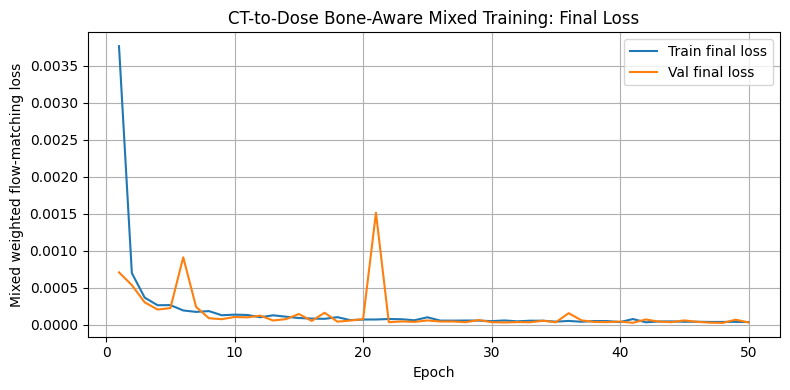

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_bone_aware_mixed_training/ct2dose_phase4_bone_aware_mixed_flow_lr5e4_base24_bs2_T0p10_a0p30_mw3_bf2_final_loss_curve.png


In [15]:
plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_final_loss"], label="Train final loss")
plt.plot(history_df["epoch"], history_df["val_final_loss"], label="Val final loss")
plt.xlabel("Epoch")
plt.ylabel("Mixed weighted flow-matching loss")
plt.title("CT-to-Dose Bone-Aware Mixed Training: Final Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()

final_loss_curve_path = OUT_DIR / f"{RUN_NAME}_final_loss_curve.png"
plt.savefig(final_loss_curve_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", final_loss_curve_path)

### Cell 16 — Base vs weighted components

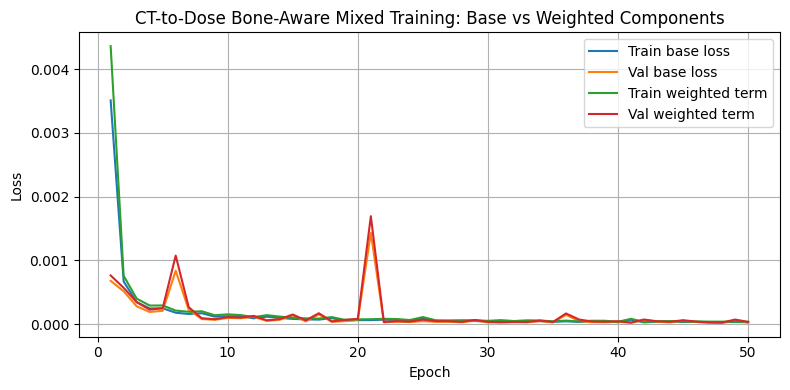

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_bone_aware_mixed_training/ct2dose_phase4_bone_aware_mixed_flow_lr5e4_base24_bs2_T0p10_a0p30_mw3_bf2_base_vs_weighted_components.png


In [16]:
plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_base_loss"], label="Train base loss")
plt.plot(history_df["epoch"], history_df["val_base_loss"], label="Val base loss")
plt.plot(history_df["epoch"], history_df["train_weighted_loss"], label="Train weighted term")
plt.plot(history_df["epoch"], history_df["val_weighted_loss"], label="Val weighted term")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CT-to-Dose Bone-Aware Mixed Training: Base vs Weighted Components")
plt.grid(True)
plt.legend()
plt.tight_layout()

component_curve_path = OUT_DIR / f"{RUN_NAME}_base_vs_weighted_components.png"
plt.savefig(component_curve_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", component_curve_path)

### Cell 17 — Simple training-label summary plot

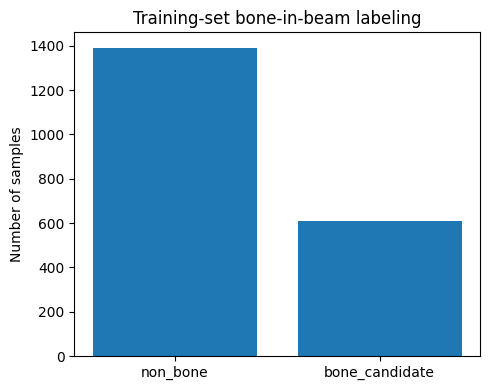

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_bone_aware_mixed_training/ct2dose_phase4_bone_aware_mixed_flow_lr5e4_base24_bs2_T0p10_a0p30_mw3_bf2_train_bone_label_counts.png


In [17]:
counts = train_label_df["bone_in_beam_candidate"].value_counts().sort_index()
labels = ["non_bone", "bone_candidate"]
values = [int(counts.get(False, 0)), int(counts.get(True, 0))]

plt.figure(figsize=(5,4))
plt.bar(labels, values)
plt.title("Training-set bone-in-beam labeling")
plt.ylabel("Number of samples")
plt.tight_layout()

label_bar_path = OUT_DIR / f"{RUN_NAME}_train_bone_label_counts.png"
plt.savefig(label_bar_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", label_bar_path)